In [10]:
from pathlib import Path
import os
import json
import importlib

from dotenv import load_dotenv
import Classes.helper_classes as helper_classes
import Classes.sql2graph_classes as sql2graph_classes

# Backward-compatibility shim for stale kernels with older adapter class.
if not hasattr(helper_classes.HuggingFaceLLMAdapter, "invoke_messages"):
    def _invoke_messages(self, messages):
        if hasattr(self.wrapper, "invoke"):
            response = self.wrapper.invoke(list(messages))
            return response.content if hasattr(response, "content") else str(response)
        response = self.wrapper(list(messages))
        return response.content if hasattr(response, "content") else str(response)

    helper_classes.HuggingFaceLLMAdapter.invoke_messages = _invoke_messages

# Reload helper first, then SQL2Graph so extractor picks updated adapter.
helper_classes = importlib.reload(helper_classes)
sql2graph_classes = importlib.reload(sql2graph_classes)

SQL2GraphParser = sql2graph_classes.SQL2GraphParser
SQL2GraphLLMExtractor = sql2graph_classes.SQL2GraphLLMExtractor
SQL2GraphPipeline = sql2graph_classes.SQL2GraphPipeline
SQL2GraphVisualizer = sql2graph_classes.SQL2GraphVisualizer

load_dotenv()
HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN is missing. Add HF_TOKEN to .env and restart the kernel.")

print(f"HF_TOKEN loaded: ...{HF_TOKEN[-6:]}")

HF_TOKEN loaded: ...OrZWkc


In [11]:
data_path = Path("data") / "SQL_valid.txt"
if not data_path.exists():
    raise FileNotFoundError(f"Could not find {data_path}")

raw_sql = data_path.read_text(encoding="utf-8")

# Simple statement splitter (good enough for initial testing)
statements = [s.strip() for s in raw_sql.split(";") if s.strip()]

print(f"Loaded {len(raw_sql):,} characters from {data_path}")
print(f"Detected {len(statements)} SQL statement(s)")
print("\nFirst statement preview:\n")
print(statements[0][:1200])

Loaded 4,935 characters from data/SQL_valid.txt
Detected 1 SQL statement(s)

First statement preview:

INSERT INTO s_grnplm_vd_t_bvd_db_dmslcl.d_agr_cred_dmcl_attr  WITH cte_agr_cred_qlty_period AS (
         SELECT crd.host_eks_agr_id,
            t.start_dt,
            t.end_dt,
            t.agr_qlty_cat_type_id,
            t.agr_srv_qlty_type_id,
            t.cred_worthiness_id,
            t.prvsn_port_flag
           FROM (s_grnplm_vd_t_bvd_db_dmcl.a_agr_cred_qlty_period t
             JOIN s_grnplm_vd_t_bvd_db_dmcl.d_agr_cred crd ON ((t.agr_cred_id = crd.agr_cred_id)))
          WHERE (crd.agr_cred_id = crd.prnt_agr_cred_id)
        ), pprb_attr_val AS (
         SELECT cte_agr_cred_qlty_period.host_eks_agr_id,
            cte_agr_cred_qlty_period.start_dt,
            cte_agr_cred_qlty_period.end_dt,
            'agr_qlty_cat_type_id'::text AS attr_name,
            NULL::numeric AS attr_val_numeric,
            cte_agr_cred_qlty_period.agr_qlty_cat_type_id AS attr_val_uuid,

In [12]:
MODEL = "Qwen/Qwen3-Coder-30B-A3B-Instruct"
PROVIDER = "scaleway"

parser = SQL2GraphParser()
llm_extractor = SQL2GraphLLMExtractor(
    model=MODEL,
    provider=PROVIDER,
    hf_token=HF_TOKEN,
    max_new_tokens=3072,
    temperature=0.0,
    max_retries=2,
    enable_refinement=True,  # second LLM pass for better quality lineage JSON
)
pipeline = SQL2GraphPipeline(
    llm_extractor=llm_extractor,
    parser=parser,
)

print("SQL2Graph pipeline initialized")

SQL2Graph pipeline initialized


In [13]:
# Try converting the first SQL statement from SQL_valid.txt
sql_to_test = statements[0]

result = pipeline.run(
    sql=sql_to_test,
    schema=None,
    dialect=None,
    include_visualization=True,
)

if "error" in result:
    print("ERROR:", result["error"])
    if "details" in result:
        print(result["details"])
else:
    edge_items = result["graph"].get("links", result["graph"].get("edges", []))
    print("Conversion succeeded")
    print("Warnings:", len(result.get("warnings", [])))
    print("Graph nodes:", len(result["graph"].get("nodes", [])))
    print("Graph edges:", len(edge_items))

Conversion succeeded
Warnings: 0
Graph nodes: 67
Graph edges: 98


In [14]:
# Inspect graph JSON and generated visualization text
if "error" not in result:
    edge_items = result["graph"].get("links", result["graph"].get("edges", []))

    print("\nWarnings:")
    for warning in result.get("warnings", []):
        print("-", warning)

    print("\nFirst 3 nodes:")
    print(json.dumps(result["graph"].get("nodes", [])[:3], indent=2))

    print("\nFirst 5 edges:")
    print(json.dumps(edge_items[:5], indent=2))

    print("\nMermaid preview (first 1200 chars):\n")
    print(result["visualization"]["mermaid"][:1200])


Warnings:

First 3 nodes:
[
  {
    "node_type": "output_column",
    "alias": "agr_cred_id",
    "expression": "t2.agr_cred_id",
    "aggregate": false,
    "window_function": false,
    "id": "output.agr_cred_id"
  },
  {
    "node_type": "source_column",
    "table_alias": "t2",
    "column": "agr_cred_id",
    "id": "t2.agr_cred_id"
  },
  {
    "node_type": "output_column",
    "alias": "host_agr_cred_id",
    "expression": "t1.host_agr_cred_id",
    "aggregate": false,
    "window_function": false,
    "id": "output.host_agr_cred_id"
  }
]

First 5 edges:
[
  {
    "edge_type": "DERIVED_FROM",
    "source": "t2.agr_cred_id",
    "target": "output.agr_cred_id",
    "key": 0
  },
  {
    "edge_type": "DERIVED_FROM",
    "source": "t1.host_agr_cred_id",
    "target": "output.host_agr_cred_id",
    "key": 0
  },
  {
    "edge_type": "DERIVED_FROM",
    "source": "t1.start_dt",
    "target": "output.start_dt",
    "key": 0
  },
  {
    "edge_type": "DERIVED_FROM",
    "source": "t1.e

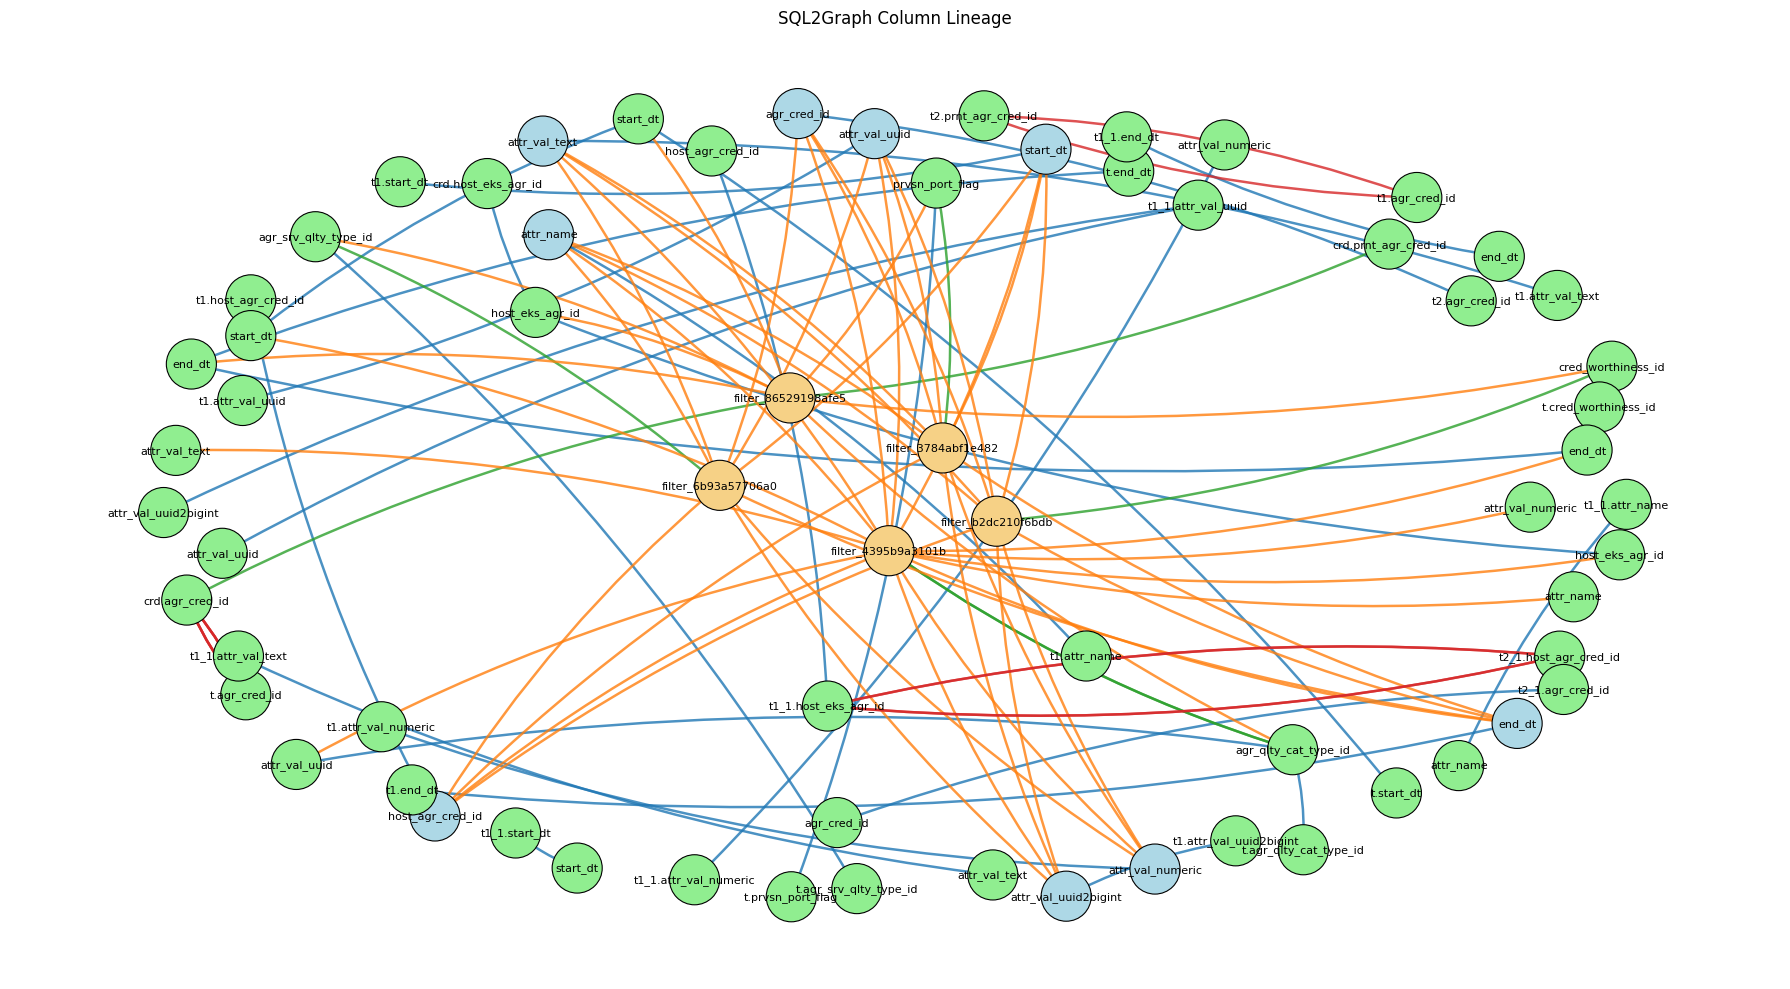

Rendered graph: 67 nodes, 98 edges


In [15]:
# Visualize the graph JSON output
if "error" not in result:
    graph_obj = SQL2GraphVisualizer.draw(
        result["graph"],
        figsize=(18, 10),
        with_labels=True,
        layout="spring",
    )
    print(f"Rendered graph: {graph_obj.number_of_nodes()} nodes, {graph_obj.number_of_edges()} edges")

In [16]:
# Optional: save the full output to disk for later inspection
output_path = Path("data") / "sql2graph_result.json"

if "error" not in result:
    output_path.write_text(json.dumps(result, indent=2), encoding="utf-8")
    print(f"Saved full SQL2Graph result to: {output_path}")

Saved full SQL2Graph result to: data/sql2graph_result.json


In [17]:
# Inspect extracted subgraphs (CTEs, JOIN blocks, UNION branches)
if "error" not in result:
    subgraphs = result.get("subgraphs", [])
    print(f"Total subgraphs: {len(subgraphs)}")

    for i, sg in enumerate(subgraphs):
        nodes = sg.get("graph", {}).get("nodes", [])
        edges = sg.get("graph", {}).get("links", sg.get("graph", {}).get("edges", []))
        print(f"[{i}] type={sg.get('type')} name={sg.get('name')} nodes={len(nodes)} edges={len(edges)}")
        sql_preview = (sg.get("sql", "") or "").replace("\n", " ")
        if sql_preview:
            print(f"     sql: {sql_preview[:140]}...")

Total subgraphs: 0


In [18]:
# Visualize a selected subgraph by index
if "error" not in result:
    subgraphs = result.get("subgraphs", [])
    subgraph_index = 0  # change index to inspect different block

    if subgraphs and 0 <= subgraph_index < len(subgraphs):
        selected = subgraphs[subgraph_index]
        print(f"Visualizing subgraph[{subgraph_index}] -> {selected.get('type')} / {selected.get('name')}")
        sg_graph_json = selected.get("graph", {"nodes": [], "links": []})
        if sg_graph_json.get("nodes"):
            SQL2GraphVisualizer.draw(sg_graph_json, figsize=(14, 8), with_labels=True, layout="spring")
        else:
            print("Selected subgraph has no mapped nodes yet (metadata-only block).")
    else:
        print("No subgraphs found or index out of range.")

No subgraphs found or index out of range.
